In [ ]:
#!/usr/bin/env python3
"""
AMOC RECONSTRUCTION PIPELINE (Marion split) — STRICT MEMBER SAFE
===============================================================

Goal:
  - Discover smallest interpretable set of latent predictors (EOF PCs)
  - Train and select features ONLY in 1850–1950 (TRAIN)
  - Evaluate on 1951–1980 (TEST)
  - Apply to 1981–2014 (LATE diagnostic: relationship breakdown)

Key design:
  - CV for hyperparameters happens ONLY inside TRAIN
  - Feature ranking happens ONLY inside fold-train (within TRAIN CV)
  - Final ranking/features derived ONLY from full TRAIN
  - TEST and LATE are never used for ranking or hyperparameter selection

Outputs saved with save_tag:
  - *_final_features.csv
  - *_train_feature_ranking.csv
  - *_cv_grid_results.csv
  - *_best_params.csv
  - *_test_predictions.csv
  - *_late_predictions.csv
  - *_test_metrics.csv
  - *_late_metrics.csv

- TRAIN: 1850–1950
- TEST:  1951–1980
- LATE:  1981–2014

Key safety:
- In member mode: MUST select one member from AMOC_XXN_member (no silent mean)
- Prints AMOC fingerprints to verify different members are actually different
- Writes outputs into separate folders per member
"""

import os
import numpy as np
import pandas as pd
import xarray as xr

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score


# ============================================================
# USER CONFIG
# ============================================================

MODEL  = "IPSL-CM6A-LR"

# IMPORTANT: Keep these explicit so you can't mix them.
TARGET_ENSMEAN = "AMOC_45N_ensmean"
TARGET_MEMBER  = "AMOC_45N_member"

MODE    = "member"                 # "ensmean" or "member"
MEMBERS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]                   # used only if MODE="member"

CFG = dict(
    EOF_DIR_TEMPLATE="/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/",
    AMOC_FILE_TEMPLATE="/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc",
    OUT_ROOT="/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/",

    YEAR_START=1850,
    YEAR_END=2014,

    TRAIN_START=1850, TRAIN_END=1950,
    TEST_START=1951,  TEST_END=1970,
    LATE_START=1971,  LATE_END=2014,

    # CV INSIDE TRAIN
    N_SPLITS=3,
    GAP_EMBARGO=0,
    MIN_CORR_POINTS=20,
    MIN_TRAIN_SAMPLES=15,  # after lag-trim
    MIN_VAL_SAMPLES=10,    # after lag-trim

    VARS=["thetao", "so"],
    LON_TAGS=["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"],
    N_MODES=10,

    MAX_LAG_TOTAL=50,
    MAX_LAG_ALLOWED=25,
    CAP_LAGS_PER_GROUP=None,

    N_LIST=[5, 10, 15],
    W_LIST=[0, 1],
    RIDGE_ALPHAS=[1e-4, 1e-3, 1e-2, 1e-1, 1, 3, 10, 30, 100, 300, 1000],

    USE_ONE_SE_RULE=True,
)

# Base outdir (we will create per-member subfolders)
BASE_OUTDIR = os.path.join(CFG["OUT_ROOT"], MODEL, ("AMOC_45N_member" if MODE=="member" else "AMOC_45N_ensmean"), f"mode_{MODE}")
os.makedirs(BASE_OUTDIR, exist_ok=True)
print("BASE_OUTDIR:", BASE_OUTDIR)


# ============================================================
# HELPERS
# ============================================================

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def years_to_idx(years, y0, y1):
    years = np.asarray(years, dtype=int)
    idx = np.where((years >= int(y0)) & (years <= int(y1)))[0].astype(int)
    if idx.size == 0:
        raise ValueError(f"No years found in range {y0}-{y1}. Available: {years[0]}–{years[-1]}")
    return idx

def load_pc(eof_dir, var, lon_tag, n_modes, member_mode=False, member_id=None):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")

    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))

    if "member" in PC.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")
            if "member" in PC.coords and member_id in PC["member"].values:
                PC = PC.sel(member=member_id)
            else:
                PC = PC.isel(member=int(member_id))
        else:
            PC = PC.mean("member")

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def _fingerprint(name, arr):
    arr = np.asarray(arr, float)
    return (f"{name}: mean={np.mean(arr):+.4f}, std={np.std(arr):.4f}, "
            f"first3={np.array2string(arr[:3], precision=4)}, "
            f"last3={np.array2string(arr[-3:], precision=4)}")

def load_amoc(amoc_file, target, member_mode=False, member_id=None, verbose=True):
    """
    STRICT AMOC loader:
    - If member_mode=True: MUST select exactly one member and remove 'member' dim.
    - If member_mode=False and 'member' exists: ensemble mean is returned.
    Always returns (year,) DataArray.
    """
    dsA = xr.open_dataset(amoc_file)
    if target not in dsA:
        raise KeyError(f"Target '{target}' not found in {amoc_file}. Available: {list(dsA.data_vars)}")

    am = dsA[target]

    # Ensure year dim exists
    if "year" not in am.dims:
        if "time" not in am.dims:
            raise ValueError(f"AMOC variable has neither 'year' nor 'time' dim: dims={am.dims}")
        years = extract_years(am["time"])
        am = am.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    # Strict member logic
    if "member" in am.dims:
        if member_mode:
            if member_id is None:
                raise ValueError("member_id must be provided for member_mode=True")

            # prefer label selection, else index
            if "member" in am.coords and member_id in am["member"].values:
                am = am.sel(member=member_id)
            else:
                am = am.isel(member=int(member_id))

            # MUST be gone now
            if "member" in am.dims:
                raise RuntimeError("Member selection failed: 'member' dim still present after selection.")
        else:
            am = am.mean("member")
    else:
        if member_mode:
            raise ValueError("Requested member_mode=True but AMOC variable has no 'member' dimension.")

    am = am.astype(float).squeeze()
    if am.ndim != 1 or "year" not in am.dims:
        raise ValueError(f"AMOC output not (year,). Got dims={am.dims}, shape={am.shape}")

    if verbose:
        tag = f"member={member_id}" if member_mode else "ensmean"
        print(f"✓ AMOC loaded: {target} ({tag})")
        print(" ", _fingerprint("  AMOC", am.values))

    return am  # (year,)

def corr_1d(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return np.nan
    aa = a[m] - np.mean(a[m])
    bb = b[m] - np.mean(b[m])
    denom = np.sqrt(np.sum(aa**2) * np.sum(bb**2))
    if denom == 0:
        return np.nan
    return float(np.sum(aa * bb) / denom)

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).squeeze()
    y_pred = np.asarray(y_pred).squeeze()
    r2 = float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan
    r  = float(np.corrcoef(y_true, y_pred)[0, 1]) if (np.std(y_true) > 0 and np.std(y_pred) > 0) else np.nan
    var_ratio = float(np.std(y_pred) / np.std(y_true)) if np.std(y_true) > 0 else np.nan
    return r2, r, var_ratio

def metrics_anom(y_true, y_pred):
    yt = np.asarray(y_true, float).squeeze()
    yp = np.asarray(y_pred, float).squeeze()
    yt = yt - np.mean(yt)
    yp = yp - np.mean(yp)
    return metrics(yt, yp)

def rank_features_train_only(pc_np_sub, y_sub, vars_, lons_, n_modes, lags_rank):
    rows = []
    Tsub = len(y_sub)
    for var in vars_:
        for lon in lons_:
            if (var, lon) not in pc_np_sub:
                continue
            pc = pc_np_sub[(var, lon)]
            for lag in lags_rank:
                lag = int(lag)
                if lag >= Tsub:
                    continue
                t_idx = np.arange(lag, Tsub)
                p_idx = t_idx - lag
                yy = y_sub[t_idx]
                for m in range(n_modes):
                    pp = pc[p_idx, m]
                    c = corr_1d(pp, yy)
                    if np.isfinite(c):
                        rows.append(dict(
                            var=var, lon=lon, mode=int(m+1),
                            lag=int(lag), corr=float(c), abs_corr=float(abs(c))
                        ))
    df = pd.DataFrame(rows)
    if len(df) == 0:
        raise RuntimeError("No finite correlations computed in rank_features_train_only.")
    return df.sort_values("abs_corr", ascending=False).reset_index(drop=True)

def build_feature_set(df_ranked, n_seeds, W, max_lag_allowed, cap_lags_per_group=None):
    df_top = df_ranked.head(int(n_seeds))
    seeds = [(str(r.var), str(r.lon), int(r.mode)-1, int(r.lag)) for r in df_top.itertuples(index=False)]

    expanded = []
    for (var, lon, m0, lag0) in seeds:
        for L in range(lag0 - int(W), lag0 + int(W) + 1):
            if L < 0:
                continue
            if max_lag_allowed is not None and L > int(max_lag_allowed):
                continue
            expanded.append((var, lon, m0, int(L)))

    if cap_lags_per_group is not None:
        keep = []
        seen = {}
        for feat in expanded:
            key = (feat[0], feat[1], feat[2])
            seen.setdefault(key, set())
            if feat[3] not in seen[key]:
                if len(seen[key]) < int(cap_lags_per_group):
                    seen[key].add(feat[3])
                    keep.append(feat)
        expanded = keep

    return sorted(set(expanded), key=lambda x: (x[0], x[1], x[2], x[3]))

def build_XY(pc_np_full, y_full, feats, t_positions):
    t_positions = np.asarray(t_positions, int)
    max_lag = max((lag for (_, _, _, lag) in feats), default=0)
    used = t_positions[t_positions >= max_lag]
    if used.size == 0:
        return np.empty((0, len(feats))), np.empty((0,)), used, int(max_lag)

    X = np.empty((len(used), len(feats)), float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, m0]
    Y = y_full[used]
    return X, Y, used, int(max_lag)

def make_gap_folds(T_train, n_splits, gap, min_corr_points):
    base = np.arange(int(T_train), dtype=int)
    tscv = TimeSeriesSplit(n_splits=int(n_splits))
    folds = []
    for tr, va in tscv.split(base):
        tr = tr.copy()
        va = va.copy()
        if gap is not None and int(gap) > 0:
            if len(tr) <= int(gap):
                continue
            tr = tr[:-int(gap)]
        if len(tr) < int(min_corr_points) or len(va) < 10:
            continue
        folds.append((tr, va))
    return folds

def one_se_rule_choose(df_grid):
    best = df_grid.iloc[0]
    threshold = best["mean_val_r2"] - best["std_val_r2"]
    ok = df_grid[df_grid["mean_val_r2"] >= threshold].copy()
    if len(ok) == 0:
        return best.to_dict()
    ok = ok.sort_values(["N_seeds", "W", "alpha"], ascending=[True, True, False]).reset_index(drop=True)
    return ok.iloc[0].to_dict()


# ============================================================
# CORE PIPELINE
# ============================================================

def run_pipeline_one(model, mode, cfg, member_id=None, verbose=True):
    eof_dir = cfg["EOF_DIR_TEMPLATE"].format(MODEL=model)
    amoc_file = cfg["AMOC_FILE_TEMPLATE"].format(MODEL=model)

    # ----- Load PCs -----
    pc_dict = {}
    missing = []
    for var in cfg["VARS"]:
        for lon in cfg["LON_TAGS"]:
            try:
                pc_dict[(var, lon)] = load_pc(
                    eof_dir, var, lon, cfg["N_MODES"],
                    member_mode=(mode == "member"),
                    member_id=member_id
                )
            except FileNotFoundError:
                missing.append((var, lon))

    if len(pc_dict) == 0:
        raise RuntimeError("No PC files could be loaded. Check EOF_DIR and filenames.")

    available_pairs = sorted(pc_dict.keys())
    vars_avail = sorted(set(v for (v, _) in available_pairs))
    lons_avail = sorted(set(l for (_, l) in available_pairs))

    # ----- Load AMOC (STRICT) -----
    if mode == "member":
        am = load_amoc(amoc_file, TARGET_MEMBER, member_mode=True, member_id=member_id, verbose=verbose)
        # sanity vs ensmean (should differ)
        ens = load_amoc(amoc_file, TARGET_MEMBER, member_mode=False, verbose=False)
        diff = float(np.nanmean(np.abs(am.values - ens.sel(year=am["year"]).values)))
        if verbose:
            print(f"  sanity |mean(abs(member - ensmean))| = {diff:.6f}")
            if diff < 1e-10:
                raise RuntimeError("Sanity check failed: member series identical to ensmean. Member selection is NOT working.")
    else:
        am = load_amoc(amoc_file, TARGET_ENSMEAN, member_mode=False, verbose=verbose)

    # ----- Align years -----
    common_years = am["year"].values.astype(int)
    for da in pc_dict.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= cfg["YEAR_START"]) & (common_years <= cfg["YEAR_END"])]

    y_full = am.sel(year=common_years).values.astype(float).squeeze()
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_dict.items()}

    idx_train = years_to_idx(common_years, cfg["TRAIN_START"], cfg["TRAIN_END"])
    idx_test  = years_to_idx(common_years, cfg["TEST_START"],  cfg["TEST_END"])
    idx_late  = years_to_idx(common_years, cfg["LATE_START"],  cfg["LATE_END"])

    if verbose:
        print(f"\n✓ YEARS total: {common_years[0]}–{common_years[-1]} (T={len(common_years)})")
        print(f"✓ TRAIN: {cfg['TRAIN_START']}–{cfg['TRAIN_END']} (T={len(idx_train)})")
        print(f"✓ TEST:  {cfg['TEST_START']}–{cfg['TEST_END']} (T={len(idx_test)})")
        print(f"✓ LATE:  {cfg['LATE_START']}–{cfg['LATE_END']} (T={len(idx_late)})")
        print(" ", _fingerprint("TRAIN y", y_full[idx_train]))
        print(" ", _fingerprint("TEST  y", y_full[idx_test]))
        print(" ", _fingerprint("LATE  y", y_full[idx_late]))
        print("✓ Available VARS:", vars_avail)
        print("✓ Available LONS:", lons_avail)

    lags = np.arange(0, int(cfg["MAX_LAG_TOTAL"]), dtype=int)
    if cfg["MAX_LAG_ALLOWED"] is not None:
        lags = lags[lags <= int(cfg["MAX_LAG_ALLOWED"])]

    folds = make_gap_folds(
        T_train=len(idx_train),
        n_splits=cfg["N_SPLITS"],
        gap=cfg["GAP_EMBARGO"],
        min_corr_points=cfg["MIN_CORR_POINTS"],
    )
    if len(folds) < 2:
        raise RuntimeError("Too few folds in TRAIN. Reduce N_SPLITS or MIN_CORR_POINTS or GAP_EMBARGO.")

    if verbose:
        print("FOLDS USED:", len(folds))
        for i, (tr, va) in enumerate(folds):
            print(i, "train:", len(tr), "val:", len(va))
        print("\nRunning TimeSeriesSplit CV on TRAIN only...")

    grid_rows = []
    for N_seeds in cfg["N_LIST"]:
        for W in cfg["W_LIST"]:
            for alpha in cfg["RIDGE_ALPHAS"]:
                r2s, cors, vrs = [], [], []

                for (tr_rel, va_rel) in folds:
                    tr_idx = idx_train[tr_rel]
                    va_idx = idx_train[va_rel]
                    y_tr = y_full[tr_idx]

                    pc_tr = {(var, lon): pc_np_full[(var, lon)][tr_idx, :] for (var, lon) in available_pairs}

                    df_rank_fold = rank_features_train_only(pc_tr, y_tr, vars_avail, lons_avail, cfg["N_MODES"], lags)
                    feats = build_feature_set(df_rank_fold, N_seeds, W, cfg["MAX_LAG_ALLOWED"], cfg["CAP_LAGS_PER_GROUP"])

                    Xtr, Ytr, _, _ = build_XY(pc_np_full, y_full, feats, tr_idx)
                    Xva, Yva, _, _ = build_XY(pc_np_full, y_full, feats, va_idx)

                    if len(Ytr) < cfg["MIN_TRAIN_SAMPLES"] or len(Yva) < cfg["MIN_VAL_SAMPLES"]:
                        continue

                    mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(alpha)))
                    mdl.fit(Xtr, Ytr)
                    pred = mdl.predict(Xva)

                    r2, r, vr = metrics(Yva, pred)
                    r2s.append(r2); cors.append(r); vrs.append(vr)

                if len(r2s) < 2:
                    continue

                mean_r2 = float(np.mean(r2s))
                std_r2  = float(np.std(r2s))

                if verbose:
                    print(f"  N={N_seeds:2d} W={W} alpha={alpha:<7g} | val R²={mean_r2: .4f} ±{std_r2:.4f} (folds={len(r2s)})")

                grid_rows.append(dict(
                    N_seeds=int(N_seeds), W=int(W), alpha=float(alpha),
                    mean_val_r2=mean_r2, std_val_r2=std_r2,
                    mean_val_corr=float(np.mean(cors)),
                    mean_val_var_ratio=float(np.mean(vrs)),
                    n_folds_used=int(len(r2s)),
                ))

    if len(grid_rows) == 0:
        raise RuntimeError("No CV rows produced. Try reducing MAX_LAG_ALLOWED, W, or N_SPLITS.")

    df_grid = (pd.DataFrame(grid_rows)
               .sort_values(["mean_val_r2", "std_val_r2"], ascending=[False, True])
               .reset_index(drop=True))
    best = one_se_rule_choose(df_grid) if cfg["USE_ONE_SE_RULE"] else df_grid.iloc[0].to_dict()

    # Final ranking on full TRAIN
    y_tr_full = y_full[idx_train]
    pc_tr_full = {(var, lon): pc_np_full[(var, lon)][idx_train, :] for (var, lon) in available_pairs}
    df_rank_train = rank_features_train_only(pc_tr_full, y_tr_full, vars_avail, lons_avail, cfg["N_MODES"], lags)

    feats_final = build_feature_set(df_rank_train, int(best["N_seeds"]), int(best["W"]),
                                    cfg["MAX_LAG_ALLOWED"], cfg["CAP_LAGS_PER_GROUP"])

    Xtr_all, Ytr_all, used_tr, maxlag_final = build_XY(pc_np_full, y_full, feats_final, idx_train)
    final_model = make_pipeline(StandardScaler(), Ridge(alpha=float(best["alpha"])))
    final_model.fit(Xtr_all, Ytr_all)

    pred_tr = final_model.predict(Xtr_all)
    a, b = np.polyfit(pred_tr, Ytr_all, 1)

    # TEST
    Xte, Yte, used_te, _ = build_XY(pc_np_full, y_full, feats_final, idx_test)
    pred_te = final_model.predict(Xte)
    pred_te_cal = a * pred_te + b
    test_r2, test_corr, test_var = metrics(Yte, pred_te_cal)
    test_r2_a, test_corr_a, test_var_a = metrics_anom(Yte, pred_te_cal)

    # LATE
    Xla, Yla, used_la, _ = build_XY(pc_np_full, y_full, feats_final, idx_late)
    pred_la = final_model.predict(Xla)
    pred_la_cal = a * pred_la + b
    late_r2, late_corr, late_var = metrics(Yla, pred_la_cal)
    late_r2_a, late_corr_a, late_var_a = metrics_anom(Yla, pred_la_cal)

    return dict(
        df_grid=df_grid,
        best=best,
        df_rank_train=df_rank_train,
        feats_final=feats_final,
        years=common_years,
        idx_train=idx_train, idx_test=idx_test, idx_late=idx_late,
        calibration=dict(a=float(a), b=float(b)),
        train_metrics=dict(
            train_r2=float(r2_score(Ytr_all, a*pred_tr+b)),
            train_corr=float(np.corrcoef(Ytr_all, a*pred_tr+b)[0, 1]) if np.std(Ytr_all) > 0 else np.nan,
            train_var_ratio=float(np.std(a*pred_tr+b)/np.std(Ytr_all)) if np.std(Ytr_all) > 0 else np.nan,
            max_lag_used=int(maxlag_final),
            n_features_used=int(len(feats_final)),
        ),
        test_metrics=dict(
            test_r2=float(test_r2), test_corr=float(test_corr), test_var_ratio=float(test_var),
            test_r2_anom=float(test_r2_a), test_corr_anom=float(test_corr_a), test_var_ratio_anom=float(test_var_a),
            max_lag_used=int(maxlag_final), n_features_used=int(len(feats_final)),
        ),
        late_metrics=dict(
            late_r2=float(late_r2), late_corr=float(late_corr), late_var_ratio=float(late_var),
            late_r2_anom=float(late_r2_a), late_corr_anom=float(late_corr_a), late_var_ratio_anom=float(late_var_a),
            max_lag_used=int(maxlag_final), n_features_used=int(len(feats_final)),
        ),
        test_pred_df=pd.DataFrame(dict(year=common_years[used_te], y_true=Yte, y_pred=pred_te_cal)),
        late_pred_df=pd.DataFrame(dict(year=common_years[used_la], y_true=Yla, y_pred=pred_la_cal)),
        member_id=member_id,
    )


def save_run(res, outdir):
    save_tag = (
        f"TESTR2_{res['test_metrics']['test_r2']:.3f}"
        f"_N{int(res['best']['N_seeds'])}"
        f"_W{int(res['best']['W'])}"
        f"_A{float(res['best']['alpha']):g}"
    )
    if res["member_id"] is not None:
        save_tag += f"_member{res['member_id']}"

    os.makedirs(outdir, exist_ok=True)

    res["df_grid"].to_csv(os.path.join(outdir, f"{save_tag}_cv_grid_results.csv"), index=False)
    pd.DataFrame([res["best"]]).to_csv(os.path.join(outdir, f"{save_tag}_best_params.csv"), index=False)
    res["df_rank_train"].to_csv(os.path.join(outdir, f"{save_tag}_train_feature_ranking.csv"), index=False)

    df_feats = pd.DataFrame([
        {"var": v, "lon": lon, "mode": int(m)+1, "mode0": int(m), "lag": int(lag)}
        for (v, lon, m, lag) in res["feats_final"]
    ])
    df_feats.to_csv(os.path.join(outdir, f"{save_tag}_final_features.csv"), index=False)

    res["test_pred_df"].to_csv(os.path.join(outdir, f"{save_tag}_test_predictions.csv"), index=False)
    res["late_pred_df"].to_csv(os.path.join(outdir, f"{save_tag}_late_predictions.csv"), index=False)

    pd.DataFrame([res["train_metrics"]]).to_csv(os.path.join(outdir, f"{save_tag}_train_metrics.csv"), index=False)
    pd.DataFrame([res["test_metrics"]]).to_csv(os.path.join(outdir, f"{save_tag}_test_metrics.csv"), index=False)
    pd.DataFrame([res["late_metrics"]]).to_csv(os.path.join(outdir, f"{save_tag}_late_metrics.csv"), index=False)
    pd.DataFrame([res["calibration"]]).to_csv(os.path.join(outdir, f"{save_tag}_train_calibration_ab.csv"), index=False)

    print("\n✅ Saved run outputs with tag:", save_tag)
    print("   folder:", outdir)
    return save_tag


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":

    if MODE == "ensmean":
        print("\n===== ENSEMBLE MEAN =====")
        run_outdir = os.path.join(BASE_OUTDIR, "ensmean")
        res = run_pipeline_one(MODEL, mode="ensmean", cfg=CFG, member_id=None, verbose=True)
        print("\nBEST:", res["best"])
        print("TEST:", res["test_metrics"])
        print("LATE:", res["late_metrics"])
        save_run(res, run_outdir)

    else:
        for mid in MEMBERS:
            print("\n===============================")
            print(" Running MEMBER:", mid)
            print("===============================")

            run_outdir = os.path.join(BASE_OUTDIR, f"member_{int(mid):03d}")
            res = run_pipeline_one(MODEL, mode="member", cfg=CFG, member_id=mid, verbose=True)
            print("\nBEST:", res["best"])
            print("TEST:", res["test_metrics"])
            print("LATE:", res["late_metrics"])
            save_run(res, run_outdir)


In [ ]:
#!/usr/bin/env python3
"""
FIGURE SCRIPT
====================================

Loads one saved run (SAVE_TAG) from PIPE_DIR and produces:
  01_EOF_PC     : old-style EOF + PC (spaghetti) panels for selected (var, lon, mode)
  02_HIST       : contribution histograms (sum |corr| by mode)
  03_FEATUREMAP : feature map table (lags listed, shading by |corr|)
  04_RECON      : TEST reconstruction and LATE reconstruction plots

Note:
  Ranking file here is TRAIN-only ranking, by design.
"""

import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# ----------------------------
# USER SETTINGS
# ----------------------------
MODEL   = "IPSL-CM6A-LR"
TARGET  = "AMOC_45N_member"
MODE    = "member"      # "ensmean" or "member"
member_id = "TESTR2_-1.906_N5_W1_A100_member32"         # if MODE="member" set int/label

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

EOF_DIR   = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

PIPE_DIR = f"/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/{MODEL}/{TARGET}/mode_{MODE}/"

# ✅ Choose which run tag you want to plot (copy from pipeline printout)
SAVE_TAG = "TESTR2_-1.683_N5_W0_A1000"   # example

FEAT_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_final_features.csv")
RANK_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_train_feature_ranking.csv")
TEST_PRED_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_predictions.csv")
LATE_PRED_CSV = os.path.join(PIPE_DIR, f"{SAVE_TAG}_late_predictions.csv")
TEST_MET_CSV  = os.path.join(PIPE_DIR, f"{SAVE_TAG}_test_metrics.csv")
LATE_MET_CSV  = os.path.join(PIPE_DIR, f"{SAVE_TAG}_late_metrics.csv")

OUTDIR = f"/data/users/frekle/AMOC_analysis/THESIS_FIGURES/{MODEL}/{TARGET}/{MODE}/{SAVE_TAG}/"
os.makedirs(OUTDIR, exist_ok=True)

MAX_EOF_PANELS = 6


# ============================================================
# UTIL
# ============================================================

def savefig(outbase, dpi=220):
    plt.savefig(outbase + ".png", dpi=dpi, bbox_inches="tight")
    plt.savefig(outbase + ".pdf", dpi=dpi, bbox_inches="tight")

def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def symmetric_clim(field):
    vmax = np.nanmax(np.abs(field))
    return -vmax, vmax

def load_pc_with_members(var, lon_tag, n_modes, eof_dir):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, n_modes))
    PC = PC.transpose(..., "time", "mode")  # keeps member if present
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
    return PC.astype(float)

def load_eof_map(var, lon_tag, eof_dir, mode_index_1based):
    f = os.path.join(eof_dir, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)

    eof_name = "EOF" if "EOF" in ds.data_vars else None
    if eof_name is None:
        # try common alternatives
        for c in ["eof", "patterns", "EOFs"]:
            if c in ds.data_vars:
                eof_name = c
                break
    if eof_name is None:
        raise KeyError(f"No EOF variable found in {f}. data_vars={list(ds.data_vars)}")

    EOF = ds[eof_name]
    m0 = int(mode_index_1based) - 1
    EOFm = EOF.isel(mode=m0)

    depth_dim = next((d for d in ["depth","lev","z","olevel"] if d in EOFm.dims), None)
    if depth_dim is None:
        raise KeyError(f"Could not detect depth dimension. dims={EOFm.dims}")

    lat_dim = next((d for d in ["lat","latitude","lat_index","y","j"] if d in EOFm.dims), None)
    if lat_dim is None:
        others = [d for d in EOFm.dims if d != depth_dim]
        if len(others) != 1:
            raise KeyError(f"Could not detect lat dimension. dims={EOFm.dims}")
        lat_dim = others[0]

    EOFm = EOFm.transpose(lat_dim, depth_dim)  # to (lat, depth) like old script expected
    lat = ds["lat"].values if "lat" in ds.coords else np.arange(EOFm.sizes[lat_dim])
    depth = ds["depth"].values if "depth" in ds.coords else EOFm[depth_dim].values

    # old script used eof.T with pcolormesh(lat, depth, eof.T)
    eof_lat_depth = EOFm.values.astype(float)  # (lat, depth)
    return eof_lat_depth, lat, depth, ds

def plot_oldstyle_eof_pc_panels(feats, outdir, max_panels=6):
    os.makedirs(outdir, exist_ok=True)

    uniq = []
    seen = set()
    for (var, lon, mode0, lag) in feats:
        key = (var, lon, int(mode0))
        if key not in seen:
            seen.add(key)
            uniq.append(key)
    uniq = uniq[:max_panels]

    for (var, lon, mode0) in uniq:
        mode1 = int(mode0) + 1

        eof_lat_depth, lat, depth, ds = load_eof_map(var, lon, EOF_DIR, mode1)
        vmin, vmax = symmetric_clim(eof_lat_depth)

        # variance fraction (optional)
        var_exp_txt = ""
        if "variance_fraction" in ds:
            vf = ds["variance_fraction"].values
            if len(vf) >= mode1:
                var_exp_txt = f" ({vf[mode1-1]*100:.1f}% variance)"

        PC = load_pc_with_members(var, lon, N_MODES, EOF_DIR)

        # select PC for this mode
        if "member" in PC.dims:
            pcs = PC.isel(mode=int(mode0))               # (member, year)
            pcs_mean = pcs.mean("member")
            pcs_std  = pcs.std("member")
            years = pcs["year"].values
        else:
            pcs = PC.isel(mode=int(mode0))               # (year,)
            pcs_mean = pcs
            pcs_std  = None
            years = pcs["year"].values

        fig, axes = plt.subplots(
            1, 2,
            figsize=(15, 5),
            gridspec_kw={"width_ratios": [1.3, 2.0]}
        )
        fig.suptitle(
            f"{MODEL} — {var} — {lon}\nEOF {mode1}{var_exp_txt}",
            fontsize=14
        )

        # LEFT: EOF pattern (match your old pcolormesh style)
        pcm = axes[0].pcolormesh(
            lat,
            depth,
            eof_lat_depth.T,    # old script did eof.T
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
            shading="nearest"
        )
        axes[0].invert_yaxis()
        axes[0].set_xlabel("Latitude (°)")
        axes[0].set_ylabel("Depth (m)")
        axes[0].set_title("EOF pattern")
        cbar = plt.colorbar(pcm, ax=axes[0], shrink=0.8)
        cbar.set_label("EOF loading")

        # RIGHT: PC time series spaghetti + mean + ±1σ
        if "member" in PC.dims:
            for mem in range(pcs.sizes["member"]):
                axes[1].plot(years, pcs.isel(member=mem).values, color="gray", alpha=0.3, lw=0.6)
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)
            axes[1].fill_between(
                years,
                (pcs_mean - pcs_std).values,
                (pcs_mean + pcs_std).values,
                color="red",
                alpha=0.2,
                label="±1σ"
            )
        else:
            axes[1].plot(years, pcs_mean.values, color="black", lw=2)

        axes[1].axhline(0, color="black", lw=0.8)
        axes[1].grid(alpha=0.3)
        axes[1].set_xlabel("Year")
        axes[1].set_title("PC time series")

        fig.tight_layout(rect=[0, 0, 1, 0.92])
        outfile = os.path.join(outdir, f"EOF_latdepth_mode_{mode1:02d}_{var}_{lon}.png")
        fig.savefig(outfile, dpi=150)
        plt.close(fig)
        print("💾 Saved", outfile)

def plot_feature_contribution_histograms(df_rank, feats, outdir):
    os.makedirs(outdir, exist_ok=True)
    df = df_rank.copy()

    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var", "lon", "mode0", "lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    rows = []
    for (var, lon, mode0, lag) in feats:
        rows.append({"var": var, "lon": lon, "mode1": int(mode0)+1, "lag": int(lag),
                     "abs_corr": lookup.get((var, lon, int(mode0), int(lag)), 0.0)})
    df_sel = pd.DataFrame(rows)

    for var in sorted(df_sel["var"].unique()):
        d = df_sel[df_sel["var"] == var]
        by_mode = d.groupby("mode1")["abs_corr"].sum().reindex(range(1, N_MODES+1), fill_value=0.0)

        plt.figure(figsize=(8.5, 3.8))
        plt.bar(by_mode.index.values, by_mode.values)
        plt.xlabel("Mode")
        plt.ylabel("Sum |corr| (TRAIN ranking)")
        plt.title(f"{MODEL} {TARGET} | {var} | Sum |corr| contribution by mode")
        savefig(os.path.join(outdir, f"Hist_sumAbsCorr_byMode_{var}"))
        plt.show()

    return df_sel

def _make_lag_grid(feats, var, lon_tags, n_modes):
    grid = np.full((len(lon_tags), n_modes), "", dtype=object)
    d = {}
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        d.setdefault((lon, int(mode0)), set()).add(int(lag))
    for i, lon in enumerate(lon_tags):
        for m0 in range(n_modes):
            lags = sorted(d.get((lon, m0), []))
            if len(lags) == 0:
                grid[i, m0] = ""
            elif len(lags) <= 4:
                grid[i, m0] = ",".join(map(str, lags))
            else:
                grid[i, m0] = f"{lags[0]}…{lags[-1]} ({len(lags)})"
    return grid

def _importance_grid_from_corr(feats, df_rank, var, lon_tags, n_modes):
    df = df_rank.copy()
    if "mode0" not in df.columns and "mode" in df.columns:
        df["mode0"] = df["mode"].astype(int) - 1
    if "abs_corr" not in df.columns and "corr" in df.columns:
        df["abs_corr"] = df["corr"].abs()

    df_key = df.groupby(["var","lon","mode0","lag"], as_index=False)["abs_corr"].max()
    lookup = {(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])): float(r["abs_corr"])
              for _, r in df_key.iterrows()}

    grid = np.zeros((len(lon_tags), n_modes), float)
    for (v, lon, mode0, lag) in feats:
        if v != var:
            continue
        if lon not in lon_tags:
            continue
        grid[lon_tags.index(lon), int(mode0)] += lookup.get((v, lon, int(mode0), int(lag)), 0.0)
    return grid

def plot_feature_map_table(feats, df_rank, outdir):
    os.makedirs(outdir, exist_ok=True)
    grid_T = _make_lag_grid(feats, "thetao", LON_TAGS, N_MODES)
    grid_S = _make_lag_grid(feats, "so", LON_TAGS, N_MODES)
    bg_T = _importance_grid_from_corr(feats, df_rank, "thetao", LON_TAGS, N_MODES)
    bg_S = _importance_grid_from_corr(feats, df_rank, "so", LON_TAGS, N_MODES)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, grid, bg, varname in zip(axes, [grid_T, grid_S], [bg_T, bg_S], ["thetao", "so"]):
        im = ax.imshow(bg, aspect="auto")
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if grid[i, j] != "":
                    ax.text(j, i, grid[i, j], ha="center", va="center", fontsize=9)
        ax.set_title(varname)
        ax.set_xticks(range(N_MODES))
        ax.set_xticklabels([str(m+1) for m in range(N_MODES)])
        ax.set_xlabel("Mode")
        ax.set_yticks(range(len(LON_TAGS)))
        ax.set_yticklabels(LON_TAGS)

    fig.suptitle(f"{MODEL} {TARGET} | Feature map (n={len(feats)})")
    cbar = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85)
    cbar.set_label("Sum |corr| in cell (TRAIN ranking)")
    plt.tight_layout()
    savefig(os.path.join(outdir, "Feature_map_table"))
    plt.show()

def plot_reconstruction(pred_csv, met_csv, outdir, tag):
    os.makedirs(outdir, exist_ok=True)
    df = pd.read_csv(pred_csv)
    met = pd.read_csv(met_csv).iloc[0].to_dict() if (met_csv and os.path.exists(met_csv)) else {}
    if "test_r2" in met:
        title_extra = (
            f" | R²={met.get('test_r2', np.nan):.3f}, r={met.get('test_corr', np.nan):.3f}, var={met.get('test_var_ratio', np.nan):.2f}"
            f" | anom R²={met.get('test_r2_anom', np.nan):.3f}, anom r={met.get('test_corr_anom', np.nan):.3f}"
        )
    else:
        title_extra = f" | R²={met.get('late_r2', np.nan):.3f}, r={met.get('late_corr', np.nan):.3f}, var={met.get('late_var_ratio', np.nan):.2f}"

    plt.figure(figsize=(10.0, 4.0))
    plt.plot(df["year"], df["y_true"], label="True AMOC")
    plt.plot(df["year"], df["y_pred"], label="Reconstruction")
    plt.xlabel("Year")
    plt.ylabel("AMOC")
    plt.title(f"{MODEL} {TARGET} | {tag}{title_extra}")
    plt.legend()
    savefig(os.path.join(outdir, f"{tag}_reconstruction"))
    plt.show()


# ============================================================
# LOAD INPUTS
# ============================================================

print("✅ Using saved run:", SAVE_TAG)
print("✅ Loading from:", PIPE_DIR)

df_rank = pd.read_csv(RANK_CSV)
if "mode0" not in df_rank.columns and "mode" in df_rank.columns:
    df_rank["mode0"] = df_rank["mode"].astype(int) - 1
if "abs_corr" not in df_rank.columns and "corr" in df_rank.columns:
    df_rank["abs_corr"] = df_rank["corr"].abs()
df_rank = df_rank.sort_values("abs_corr", ascending=False).reset_index(drop=True)

df_feats = pd.read_csv(FEAT_CSV)
# we saved both mode and mode0; prefer mode0
if "mode0" in df_feats.columns:
    feats = [(r["var"], r["lon"], int(r["mode0"]), int(r["lag"])) for _, r in df_feats.iterrows()]
else:
    feats = [(r["var"], r["lon"], int(r["mode"])-1, int(r["lag"])) for _, r in df_feats.iterrows()]

print("Loaded feats:", len(feats))
print("Loaded TRAIN ranking rows:", len(df_rank))

# ============================================================
# MAKE FIGURES
# ============================================================

plot_oldstyle_eof_pc_panels(
    feats=feats,
    outdir=os.path.join(OUTDIR, "01_EOF_PC"),
    max_panels=MAX_EOF_PANELS
)

_ = plot_feature_contribution_histograms(
    df_rank=df_rank,
    feats=feats,
    outdir=os.path.join(OUTDIR, "02_HIST")
)

plot_feature_map_table(
    feats=feats,
    df_rank=df_rank,
    outdir=os.path.join(OUTDIR, "03_FEATUREMAP")
)

plot_reconstruction(
    pred_csv=TEST_PRED_CSV,
    met_csv=TEST_MET_CSV,
    outdir=os.path.join(OUTDIR, "04_RECON"),
    tag="TEST_1951_1980"
)

plot_reconstruction(
    pred_csv=LATE_PRED_CSV,
    met_csv=LATE_MET_CSV,
    outdir=os.path.join(OUTDIR, "04_RECON"),
    tag="LATE_1981_2014"
)

print("\n✅ All figures generated in:", OUTDIR)


### Member by member figure script

BASE: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member
SUMMARY_DIR: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member/_SUMMARY
Shortlist: {'breakdown_top5': [2, 14, 30, 31, 24], 'stable_top3': [19, 3, 5], 'no_skill_top3': [22, 11]}


/tmp/ipykernel_2378797/3923343369.py:273: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ax.text(float(sub["test_r2_anom"]), float(sub["late_r2_anom"]), f" {mid:03d}", fontsize=8)


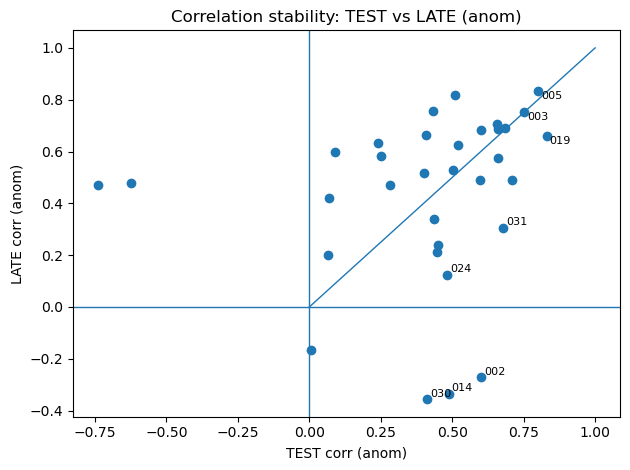

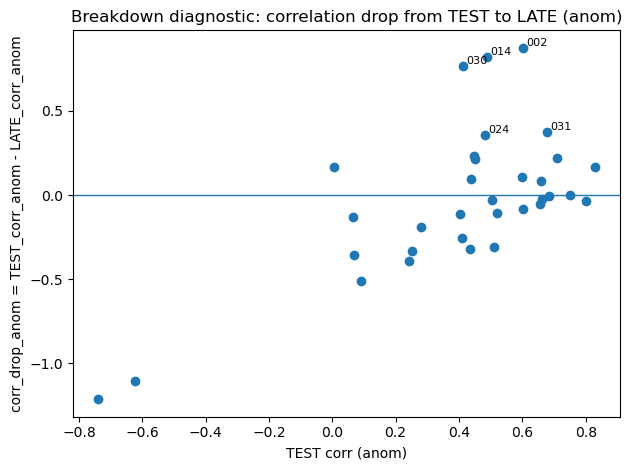

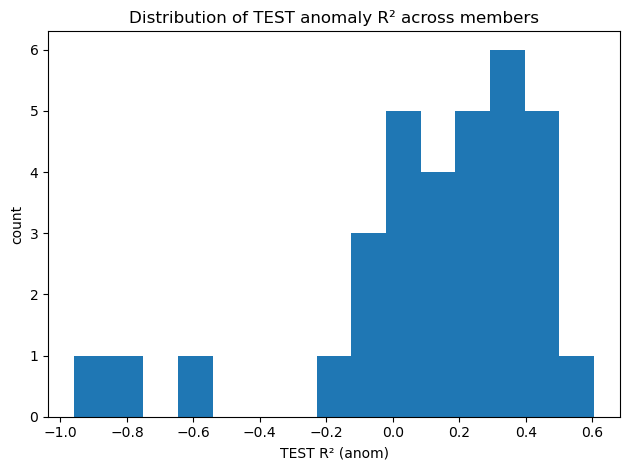

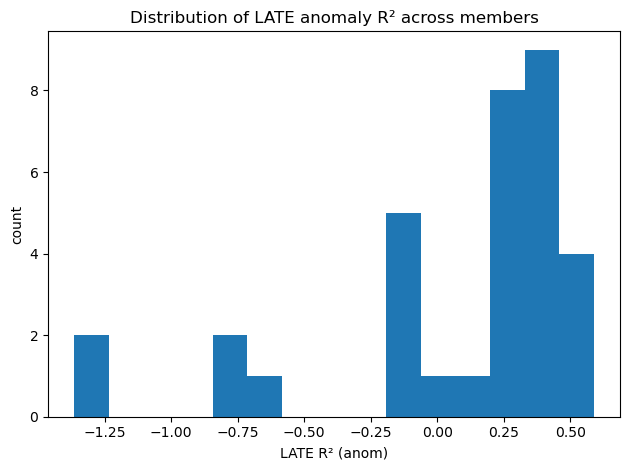

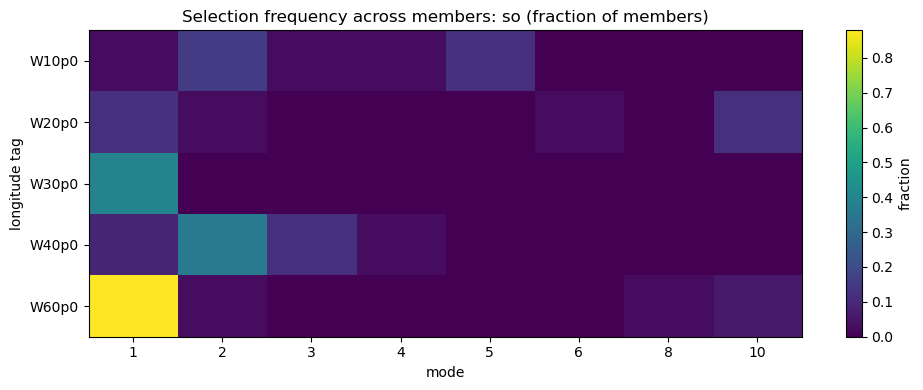

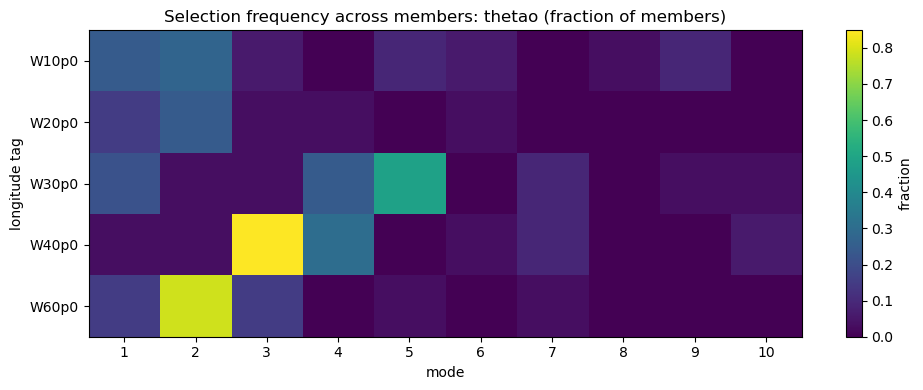

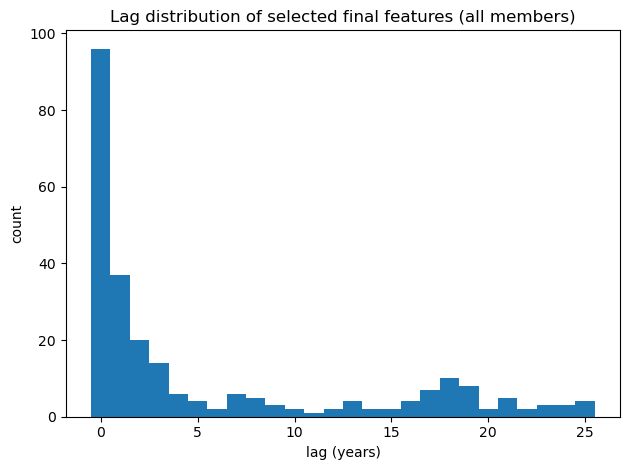

Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member/_SUMMARY/timeseries_breakdown_top5.png
Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member/_SUMMARY/timeseries_stable_top3.png
Saved: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member/_SUMMARY/timeseries_no_skill_top3.png

✅ Done. All outputs in: /data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/IPSL-CM6A-LR/AMOC_45N_member/mode_member/_SUMMARY


In [3]:
#!/usr/bin/env python3
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# CONFIG (edit these)
# =========================
MODEL = "IPSL-CM6A-LR"
TARGET_DIRNAME = "AMOC_45N_member"   # folder name inside OUT_ROOT
MODE_DIRNAME = "mode_member"         # mode folder name
OUT_ROOT = "/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/"

BASE = os.path.join(OUT_ROOT, MODEL, TARGET_DIRNAME, MODE_DIRNAME)
SUMMARY_DIR = os.path.join(BASE, "_SUMMARY")
os.makedirs(SUMMARY_DIR, exist_ok=True)

print("BASE:", BASE)
print("SUMMARY_DIR:", SUMMARY_DIR)

# =========================
# HELPERS
# =========================
def read_one_csv(pattern):
    hits = sorted(glob.glob(pattern))
    if not hits:
        return None
    return pd.read_csv(hits[0])

def find_member_id(path):
    m = re.search(r"member_(\d+)", path)
    return int(m.group(1)) if m else None

def safe_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def annotate_top(ax, df, xcol, ycol, members, dx=0.01, dy=0.01):
    for mid in members:
        sub = df[df["member"] == mid]
        if len(sub) == 0:
            continue
        x = float(sub.iloc[0][xcol])
        y = float(sub.iloc[0][ycol])
        if np.isfinite(x) and np.isfinite(y):
            ax.text(x + dx, y + dy, f"{mid:03d}", fontsize=8)

def load_member_predictions(member_dir):
    """
    Returns a single DataFrame with columns: year, y_true, y_pred
    concatenated from test + late predictions (sorted by year).
    """
    df_te = read_one_csv(os.path.join(member_dir, "*_test_predictions.csv"))
    df_la = read_one_csv(os.path.join(member_dir, "*_late_predictions.csv"))
    if df_te is None or df_la is None:
        return None

    # ensure columns exist
    for d in (df_te, df_la):
        for c in ["year", "y_true", "y_pred"]:
            if c not in d.columns:
                raise ValueError(f"Missing column '{c}' in {member_dir}")

    df_all = pd.concat([df_te[["year", "y_true", "y_pred"]],
                        df_la[["year", "y_true", "y_pred"]]], ignore_index=True)
    df_all["year"] = df_all["year"].astype(int)
    df_all = df_all.sort_values("year").reset_index(drop=True)
    return df_all

def plot_member_timeseries(ax, df_pred, title, train_end=1950, test_end=1980):
    """
    Plot y_true and y_pred for combined TEST+LATE (since those are what you saved).
    Adds vertical lines at end of TRAIN and end of TEST for orientation.
    """
    ax.plot(df_pred["year"], df_pred["y_true"], label="y_true")
    ax.plot(df_pred["year"], df_pred["y_pred"], label="y_pred")

    ax.axvline(train_end, linewidth=1)
    ax.axvline(test_end, linewidth=1)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("year")
    ax.set_ylabel("AMOC (Sv)")
    ax.grid(True, linewidth=0.3)

def make_timeseries_panel(df_metrics, member_dirs_map, members, out_png, panel_title):
    """
    Creates a stacked figure: one subplot per member.
    """
    if not members:
        print(f"⚠️ No members provided for {out_png}; skipping.")
        return

    n = len(members)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6*n), sharex=True)
    if n == 1:
        axes = [axes]

    fig.suptitle(panel_title, fontsize=14)

    for ax, mid in zip(axes, members):
        if mid not in member_dirs_map:
            ax.set_title(f"member {mid:03d} (missing folder)")
            ax.axis("off")
            continue

        mdir = member_dirs_map[mid]
        df_pred = load_member_predictions(mdir)
        if df_pred is None or len(df_pred) == 0:
            ax.set_title(f"member {mid:03d} (missing pred CSVs)")
            ax.axis("off")
            continue

        row = df_metrics[df_metrics["member"] == mid].iloc[0]
        title = (
            f"member {mid:03d} | bucket={row['bucket']} | "
            f"TEST r2_anom={row['test_r2_anom']:.3f} corr_anom={row['test_corr_anom']:.3f} | "
            f"LATE r2_anom={row['late_r2_anom']:.3f} corr_anom={row['late_corr_anom']:.3f} | "
            f"drop={row['corr_drop_anom']:.3f}"
        )

        plot_member_timeseries(ax, df_pred, title)

        # only show legend on first axis to reduce clutter
        if ax is axes[0]:
            ax.legend(loc="best")

    fig.tight_layout(rect=[0, 0.02, 1, 0.97])
    fig.savefig(out_png, dpi=200)
    plt.close(fig)
    print("Saved:", out_png)

# =========================
# COLLECT MEMBER RUNS
# =========================
member_dirs = sorted(glob.glob(os.path.join(BASE, "member_*")))
if not member_dirs:
    raise RuntimeError(f"No member_* folders found in {BASE}")

member_dirs_map = {}
rows = []
features_all = []

for mdir in member_dirs:
    mid = find_member_id(mdir)
    if mid is None:
        continue
    member_dirs_map[mid] = mdir

    df_test  = read_one_csv(os.path.join(mdir, "*_test_metrics.csv"))
    df_late  = read_one_csv(os.path.join(mdir, "*_late_metrics.csv"))
    df_train = read_one_csv(os.path.join(mdir, "*_train_metrics.csv"))
    df_best  = read_one_csv(os.path.join(mdir, "*_best_params.csv"))
    df_feats = read_one_csv(os.path.join(mdir, "*_final_features.csv"))

    if df_test is None or df_late is None or df_best is None or df_feats is None:
        print(f"⚠️ missing files for member {mid} in {mdir}")
        continue

    test  = df_test.iloc[0].to_dict()
    late  = df_late.iloc[0].to_dict()
    train = df_train.iloc[0].to_dict() if df_train is not None else {}
    best  = df_best.iloc[0].to_dict()

    row = dict(
        member=mid,
        best_N=int(best.get("N_seeds", np.nan)),
        best_W=int(best.get("W", np.nan)),
        best_alpha=safe_float(best.get("alpha", np.nan)),
        max_lag_used=int(test.get("max_lag_used", np.nan)),
        n_features_used=int(test.get("n_features_used", np.nan)),

        train_r2=safe_float(train.get("train_r2", np.nan)),
        train_corr=safe_float(train.get("train_corr", np.nan)),
        train_var_ratio=safe_float(train.get("train_var_ratio", np.nan)),

        test_r2=safe_float(test.get("test_r2", np.nan)),
        test_corr=safe_float(test.get("test_corr", np.nan)),
        test_var_ratio=safe_float(test.get("test_var_ratio", np.nan)),
        test_r2_anom=safe_float(test.get("test_r2_anom", np.nan)),
        test_corr_anom=safe_float(test.get("test_corr_anom", np.nan)),
        test_var_ratio_anom=safe_float(test.get("test_var_ratio_anom", np.nan)),

        late_r2=safe_float(late.get("late_r2", np.nan)),
        late_corr=safe_float(late.get("late_corr", np.nan)),
        late_var_ratio=safe_float(late.get("late_var_ratio", np.nan)),
        late_r2_anom=safe_float(late.get("late_r2_anom", np.nan)),
        late_corr_anom=safe_float(late.get("late_corr_anom", np.nan)),
        late_var_ratio_anom=safe_float(late.get("late_var_ratio_anom", np.nan)),
    )
    rows.append(row)

    df_feats = df_feats.copy()
    df_feats["member"] = mid
    if "mode0" not in df_feats.columns and "mode" in df_feats.columns:
        df_feats["mode0"] = df_feats["mode"].astype(int) - 1
    features_all.append(df_feats)

df = pd.DataFrame(rows).sort_values("member").reset_index(drop=True)
dfF = pd.concat(features_all, ignore_index=True)

# =========================
# BUCKETS + SCORES
# =========================
df["bucket"] = "other"
df.loc[(df["test_r2_anom"] > 0.1) & (df["late_r2_anom"] > 0.1), "bucket"] = "stable_good"
df.loc[(df["test_r2_anom"] > 0.1) & (df["late_r2_anom"] < 0.0), "bucket"] = "breakdown_late"
df.loc[(df["test_r2_anom"] < 0.0) & (df["late_r2_anom"] < 0.0), "bucket"] = "no_skill"
df.loc[(df["test_r2_anom"] < 0.0) & (df["late_r2_anom"] > 0.1), "bucket"] = "late_only"

df["corr_drop_anom"] = df["test_corr_anom"] - df["late_corr_anom"]
df["varratio_change_anom"] = df["late_var_ratio_anom"] - df["test_var_ratio_anom"]

# Save full + compact tables
df.to_csv(os.path.join(SUMMARY_DIR, "member_summary_metrics_with_buckets.csv"), index=False)

cols = [
    "member", "bucket",
    "test_r2_anom", "test_corr_anom", "test_var_ratio_anom",
    "late_r2_anom", "late_corr_anom", "late_var_ratio_anom",
    "corr_drop_anom", "varratio_change_anom",
    "best_N", "best_W", "best_alpha", "max_lag_used", "n_features_used"
]
df[cols].sort_values(["bucket", "test_r2_anom"], ascending=[True, False]).to_csv(
    os.path.join(SUMMARY_DIR, "member_listing_compact.csv"),
    index=False
)

# =========================
# SHORTLISTS
# =========================
shortlist = {}

breakdown = df[(df["bucket"] == "breakdown_late") & (df["test_corr_anom"] > 0.4)].copy()
breakdown = breakdown.sort_values("corr_drop_anom", ascending=False).head(5)
shortlist["breakdown_top5"] = breakdown["member"].tolist()

stable = df[df["bucket"] == "stable_good"].copy()
stable = stable.sort_values("test_r2_anom", ascending=False).head(3)
shortlist["stable_top3"] = stable["member"].tolist()

noskill = df[df["bucket"] == "no_skill"].copy()
noskill = noskill.sort_values("test_r2_anom", ascending=True).head(3)
shortlist["no_skill_top3"] = noskill["member"].tolist()

sl_rows = []
for k, mids in shortlist.items():
    for mid in mids:
        sl_rows.append({"set": k, "member": int(mid)})
pd.DataFrame(sl_rows).to_csv(os.path.join(SUMMARY_DIR, "member_shortlist_for_figures.csv"), index=False)

print("Shortlist:", shortlist)

# =========================
# FIGURES (scatter diagnostics)
# =========================
fig, ax = plt.subplots()
ax.scatter(df["test_r2_anom"], df["late_r2_anom"])
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlabel("TEST R² (anom)")
ax.set_ylabel("LATE R² (anom)")
ax.set_title("Generalization map: TEST vs LATE (anom)")
for mid in shortlist["breakdown_top5"]:
    sub = df[df["member"] == mid]
    if len(sub) == 0:
        continue
    ax.text(float(sub["test_r2_anom"]), float(sub["late_r2_anom"]), f" {mid:03d}", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(SUMMARY_DIR, "scatter_test_vs_late_r2_anom.png"), dpi=200)
plt.close(fig)

fig, ax = plt.subplots()
ax.scatter(df["test_corr_anom"], df["late_corr_anom"])
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.plot([0, 1], [0, 1], linewidth=1)
ax.set_xlabel("TEST corr (anom)")
ax.set_ylabel("LATE corr (anom)")
ax.set_title("Correlation stability: TEST vs LATE (anom)")
annotate_top(ax, df, "test_corr_anom", "late_corr_anom", shortlist["breakdown_top5"], dx=0.01, dy=0.01)
annotate_top(ax, df, "test_corr_anom", "late_corr_anom", shortlist["stable_top3"], dx=0.01, dy=-0.03)
fig.tight_layout()
fig.savefig(os.path.join(SUMMARY_DIR, "scatter_test_vs_late_corr_anom.png"), dpi=200)
plt.show(fig)

fig, ax = plt.subplots()
ax.scatter(df["test_corr_anom"], df["corr_drop_anom"])
ax.axhline(0, linewidth=1)
ax.set_xlabel("TEST corr (anom)")
ax.set_ylabel("corr_drop_anom = TEST_corr_anom - LATE_corr_anom")
ax.set_title("Breakdown diagnostic: correlation drop from TEST to LATE (anom)")
annotate_top(ax, df, "test_corr_anom", "corr_drop_anom", shortlist["breakdown_top5"], dx=0.01, dy=0.01)
fig.tight_layout()
fig.savefig(os.path.join(SUMMARY_DIR, "scatter_breakdown_corr_drop.png"), dpi=200)
plt.show(fig)

# histograms
plt.figure()
plt.hist(df["test_r2_anom"].dropna(), bins=15)
plt.xlabel("TEST R² (anom)")
plt.ylabel("count")
plt.title("Distribution of TEST anomaly R² across members")
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "hist_test_r2_anom.png"), dpi=200)
plt.show()

plt.figure()
plt.hist(df["late_r2_anom"].dropna(), bins=15)
plt.xlabel("LATE R² (anom)")
plt.ylabel("count")
plt.title("Distribution of LATE anomaly R² across members")
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "hist_late_r2_anom.png"), dpi=200)
plt.show()

# feature frequency heatmaps
dfF["mode"] = dfF["mode0"].astype(int) + 1
grp = dfF.groupby(["var", "lon", "mode"]).size().reset_index(name="count")
nmem = df["member"].nunique()
grp["freq"] = grp["count"] / float(nmem)

for var in sorted(dfF["var"].unique()):
    g = grp[grp["var"] == var]
    lons = sorted(g["lon"].unique())
    modes = sorted(g["mode"].unique())
    Z = np.zeros((len(lons), len(modes)))
    for _, r in g.iterrows():
        i = lons.index(r["lon"])
        j = modes.index(int(r["mode"]))
        Z[i, j] = float(r["freq"])

    plt.figure(figsize=(10, 4))
    plt.imshow(Z, aspect="auto")
    plt.yticks(np.arange(len(lons)), lons)
    plt.xticks(np.arange(len(modes)), modes)
    plt.xlabel("mode")
    plt.ylabel("longitude tag")
    plt.title(f"Selection frequency across members: {var} (fraction of members)")
    plt.colorbar(label="fraction")
    plt.tight_layout()
    plt.savefig(os.path.join(SUMMARY_DIR, f"heatmap_feature_freq_{var}.png"), dpi=200)
    plt.show()

# lag histogram
plt.figure()
lags = dfF["lag"].astype(int)
plt.hist(lags, bins=np.arange(lags.min(), lags.max()+2) - 0.5)
plt.xlabel("lag (years)")
plt.ylabel("count")
plt.title("Lag distribution of selected final features (all members)")
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, "hist_selected_lags_all_members.png"), dpi=200)
plt.show()

# =========================
# NEW: TIMESERIES PANELS
# =========================
make_timeseries_panel(
    df_metrics=df,
    member_dirs_map=member_dirs_map,
    members=shortlist["breakdown_top5"],
    out_png=os.path.join(SUMMARY_DIR, "timeseries_breakdown_top5.png"),
    panel_title="Timeseries overview: breakdown_top5 (TEST+LATE predictions)"
)

make_timeseries_panel(
    df_metrics=df,
    member_dirs_map=member_dirs_map,
    members=shortlist["stable_top3"],
    out_png=os.path.join(SUMMARY_DIR, "timeseries_stable_top3.png"),
    panel_title="Timeseries overview: stable_top3 (TEST+LATE predictions)"
)

make_timeseries_panel(
    df_metrics=df,
    member_dirs_map=member_dirs_map,
    members=shortlist["no_skill_top3"],
    out_png=os.path.join(SUMMARY_DIR, "timeseries_no_skill_top3.png"),
    panel_title="Timeseries overview: no_skill_top3 (TEST+LATE predictions)"
)

print("\n✅ Done. All outputs in:", SUMMARY_DIR)



High-fraction cells (var, lon, mode):
       var    lon  mode  n_members  freq_members
40  thetao  W40p0     3         23      0.696970
46  thetao  W60p0     2         16      0.484848
14      so  W60p0     1         15      0.454545
34  thetao  W30p0     5          9      0.272727
41  thetao  W40p0     4          9      0.272727

(v=thetao, lon=W40p0, mode=3)  cell_freq=0.697  |  lag usage (fraction of members):
 lag  freq_members  n_members
   0      0.606061         20
   1      0.030303          1
   7      0.030303          1
  13      0.030303          1
  14      0.030303          1
  15      0.030303          1
  16      0.030303          1
  17      0.030303          1
  18      0.030303          1

(v=thetao, lon=W60p0, mode=2)  cell_freq=0.485  |  lag usage (fraction of members):
 lag  freq_members  n_members
   0      0.484848         16
   1      0.151515          5
  12      0.030303          1
  17      0.030303          1
  18      0.030303          1
  19      0.03030

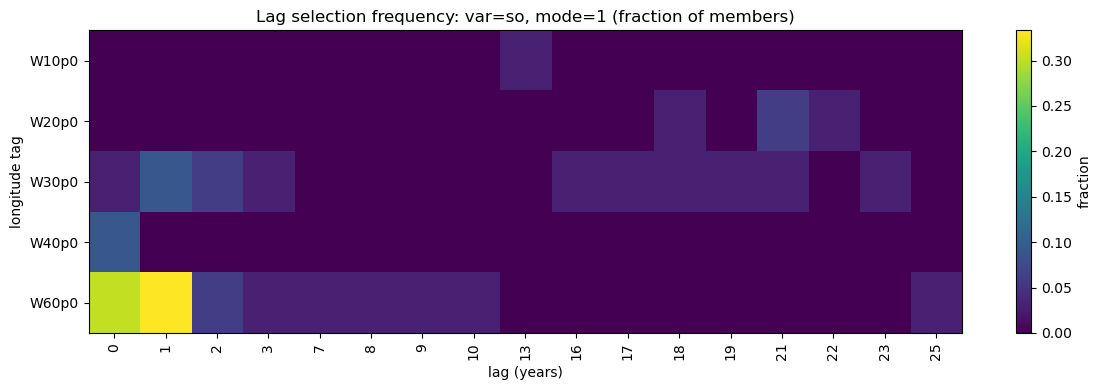

In [4]:
# =========================
# NEW: lag usage inside high-fraction (var, lon, mode) cells
# =========================

# fraction threshold: pick what you mean by "higher fraction"
FREQ_MIN = 0.25   # e.g., appears in >=25% of members (adjust)
TOPK_CELLS = 20   # or just take top N frequent cells

# 1) compute per-(var,lon,mode) member-fraction (presence, not count)
presence = (
    dfF.groupby(["var", "lon", "mode", "member"])
       .size()
       .reset_index(name="n_features_in_cell")
)
cell_frac = (
    presence.groupby(["var", "lon", "mode"])["member"]
            .nunique()
            .reset_index(name="n_members")
)
nmem = df["member"].nunique()
cell_frac["freq_members"] = cell_frac["n_members"] / float(nmem)

# choose "high fraction" cells (two options)
high_cells = cell_frac[cell_frac["freq_members"] >= FREQ_MIN].copy()
# OR: top N cells
# high_cells = cell_frac.sort_values("freq_members", ascending=False).head(TOPK_CELLS).copy()

high_cells = high_cells.sort_values("freq_members", ascending=False)

print("\nHigh-fraction cells (var, lon, mode):")
print(high_cells.head(30))

# 2) For each high cell: lag -> fraction of members that used that lag (within that cell)
lag_presence = (
    dfF.groupby(["var", "lon", "mode", "lag", "member"])
       .size()
       .reset_index(name="n")  # presence of (lag) for that member in that cell
)

lag_frac = (
    lag_presence.groupby(["var", "lon", "mode", "lag"])["member"]
                .nunique()
                .reset_index(name="n_members")
)
lag_frac["freq_members"] = lag_frac["n_members"] / float(nmem)

# Join with high_cells filter
lag_frac_high = lag_frac.merge(high_cells[["var","lon","mode"]], on=["var","lon","mode"], how="inner")

# Print a readable summary for each cell
for _, r in high_cells.iterrows():
    v, lo, mo, f = r["var"], r["lon"], int(r["mode"]), r["freq_members"]
    sub = lag_frac_high[(lag_frac_high["var"]==v) & (lag_frac_high["lon"]==lo) & (lag_frac_high["mode"]==mo)]
    sub = sub.sort_values("freq_members", ascending=False)
    print(f"\n(v={v}, lon={lo}, mode={mo})  cell_freq={f:.3f}  |  lag usage (fraction of members):")
    print(sub[["lag","freq_members","n_members"]].head(15).to_string(index=False))

# =========================
# NEW: lag heatmap for a chosen var+mode (shows which lags are common)
# =========================
CHOOSE_VAR = "so"
CHOOSE_MODE = 1   # mode number (1-based in your dfF["mode"])

sub = dfF[(dfF["var"] == CHOOSE_VAR) & (dfF["mode"] == CHOOSE_MODE)].copy()

# fraction of members using (lon, lag) within this var+mode
lag_map = (
    sub.groupby(["lon","lag","member"]).size().reset_index(name="n")
       .groupby(["lon","lag"])["member"].nunique().reset_index(name="n_members")
)
lag_map["freq_members"] = lag_map["n_members"] / float(nmem)

lons = sorted(lag_map["lon"].unique())
lags = sorted(lag_map["lag"].astype(int).unique())

Z = np.zeros((len(lons), len(lags)))
for _, r in lag_map.iterrows():
    i = lons.index(r["lon"])
    j = lags.index(int(r["lag"]))
    Z[i, j] = float(r["freq_members"])

plt.figure(figsize=(12, 4))
plt.imshow(Z, aspect="auto")
plt.yticks(np.arange(len(lons)), lons)
plt.xticks(np.arange(len(lags)), lags, rotation=90)
plt.xlabel("lag (years)")
plt.ylabel("longitude tag")
plt.title(f"Lag selection frequency: var={CHOOSE_VAR}, mode={CHOOSE_MODE} (fraction of members)")
plt.colorbar(label="fraction")
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY_DIR, f"heatmap_lagfreq_{CHOOSE_VAR}_mode{CHOOSE_MODE}.png"), dpi=200)
plt.show()



In [ ]:
#!/usr/bin/env python3
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# =========================
# CONFIG (match your setup)
# =========================
MODEL = "IPSL-CM6A-LR"
OUT_ROOT = "/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Where your member runs were saved by the pipeline:
BASE_OUTDIR = os.path.join(
    OUT_ROOT, MODEL, "AMOC_45N_member", "mode_member"
)

TARGET_TRUE = "AMOC_45N_ensmean"   # "mean amoc streamfunction" -> ensemble mean target
FIG_OUT = os.path.join(BASE_OUTDIR, f"{MODEL}_AMOC45N_member_mean_recon.png")


# =========================
# HELPERS
# =========================
def pick_latest(pattern):
    files = glob.glob(pattern)
    if not files:
        return None
    files.sort(key=lambda f: os.path.getmtime(f))
    return files[-1]

def load_true_amoc(amoc_file, varname):
    ds = xr.open_dataset(amoc_file)
    if varname not in ds:
        raise KeyError(f"{varname} not found in {amoc_file}. Available: {list(ds.data_vars)}")
    da = ds[varname]

    # ensure year dim
    if "year" not in da.dims:
        if "time" not in da.dims:
            raise ValueError(f"AMOC variable has neither 'year' nor 'time' dims: {da.dims}")
        years = xr.DataArray(da["time"]).dt.year.values.astype(int)
        da = da.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")

    # ensemble mean if member dim exists
    if "member" in da.dims:
        da = da.mean("member")

    da = da.squeeze()
    if da.ndim != 1 or "year" not in da.dims:
        raise ValueError(f"True AMOC not 1D over year. dims={da.dims}, shape={da.shape}")
    return da.astype(float)


# =========================
# LOAD MEMBER PREDICTIONS
# =========================
member_dirs = sorted(glob.glob(os.path.join(BASE_OUTDIR, "member_*")))
if not member_dirs:
    raise RuntimeError(f"No member directories found under: {BASE_OUTDIR}")

series = {}
used_members = []

for d in member_dirs:
    member_tag = os.path.basename(d)  # e.g. member_003

    f_test = pick_latest(os.path.join(d, "*_test_predictions.csv"))
    f_late = pick_latest(os.path.join(d, "*_late_predictions.csv"))

    if (f_test is None) and (f_late is None):
        print(f"Skipping {member_tag}: no prediction files found.")
        continue

    parts = []
    if f_test is not None:
        parts.append(pd.read_csv(f_test))
    if f_late is not None:
        parts.append(pd.read_csv(f_late))

    df = pd.concat(parts, ignore_index=True)
    if "year" not in df or "y_pred" not in df:
        print(f"Skipping {member_tag}: missing year/y_pred columns.")
        continue

    df = df.sort_values("year").drop_duplicates("year")
    s = pd.Series(df["y_pred"].values, index=df["year"].values.astype(int), name=member_tag)

    series[member_tag] = s
    used_members.append(member_tag)

if not series:
    raise RuntimeError("No usable member prediction series were loaded.")

# Align to common years across members (so the mean is apples-to-apples)
common_years = None
for s in series.values():
    yrs = s.index.values
    common_years = yrs if common_years is None else np.intersect1d(common_years, yrs)

common_years = np.asarray(common_years, int)
common_years.sort()

# Build matrix: (n_years, n_members)
M = np.column_stack([series[m].reindex(common_years).values for m in used_members])
mean_pred = np.nanmean(M, axis=1)
std_pred  = np.nanstd(M, axis=1)

# True AMOC (ensemble mean), restricted to same years
true_amoc = load_true_amoc(AMOC_FILE, TARGET_TRUE)
true_amoc = true_amoc.sel(year=common_years).values


# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 5))

# individual members (light grey)
for j, m in enumerate(used_members):
    plt.plot(common_years, M[:, j], color="0.80", linewidth=1.0, alpha=0.8)

# member-mean reconstruction (bold)
plt.plot(common_years, mean_pred, color="k", linewidth=2.5, label="Mean reconstruction (across members)")

# optional spread shading (uncomment if you want)
plt.fill_between(common_years, mean_pred - std_pred, mean_pred + std_pred, color="0.75", alpha=0.25, label="±1σ across members")

# true AMOC ensemble mean
plt.plot(common_years, true_amoc, linewidth=2.5, label="True AMOC (ensemble mean)")

plt.title(f"{MODEL} — AMOC 45N: member reconstructions + mean vs true ensmean")
plt.xlabel("Year")
plt.ylabel("AMOC streamfunction (units as in AMOC file)")
plt.legend(frameon=False, ncol=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(FIG_OUT, dpi=200)
print("Saved figure:", FIG_OUT)
plt.show()


In [ ]:
# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 5))

# spread shading (variability across members)
plt.fill_between(
    common_years,
    mean_pred - std_pred,
    mean_pred + std_pred,
    alpha=0.25,
    label="±1σ across members"
)

# member-mean reconstruction (bold)
plt.plot(
    common_years,
    mean_pred,
    linewidth=2.5,
    label="Mean reconstruction (across members)"
)

# true AMOC ensemble mean
plt.plot(
    common_years,
    true_amoc,
    linewidth=2.5,
    label="True AMOC (ensemble mean)"
)

plt.title(f"{MODEL} — AMOC 45N: mean reconstruction vs true ensmean")
plt.xlabel("Year")
plt.ylabel("AMOC streamfunction (units as in AMOC file)")
plt.legend(frameon=False)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.savefig(FIG_OUT, dpi=200)
print("Saved figure:", FIG_OUT)
plt.show()


In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
MODEL = "IPSL-CM6A-LR"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# Pick which AMOC variable to plot:
AMOC_MEMBER_VAR = "AMOC_45N_member"   # should have dims like ('member','year') or ('member','time')
AMOC_ENSMEAN_VAR = "AMOC_45N_ensmean" # optional; will be used if present, otherwise computed

YEAR_MIN = 1850
YEAR_MAX = 2014

FIG_OUT = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}_45N_all_members_plus_mean.png"


# =========================
# HELPERS
# =========================
def to_year_dim(da):
    """Ensure DataArray uses 'year' as its dimension, derived from 'time' if needed."""
    if "year" in da.dims:
        return da
    if "time" in da.dims:
        years = xr.DataArray(da["time"]).dt.year.values.astype(int)
        da = da.assign_coords(year=("time", years)).swap_dims({"time": "year"}).drop_vars("time")
        return da
    raise ValueError(f"DataArray has neither 'year' nor 'time' dim. dims={da.dims}")


# =========================
# LOAD
# =========================
ds = xr.open_dataset(AMOC_FILE)

if AMOC_MEMBER_VAR not in ds:
    raise KeyError(f"{AMOC_MEMBER_VAR} not found in {AMOC_FILE}. Available: {list(ds.data_vars)}")

am_m = ds[AMOC_MEMBER_VAR]
am_m = to_year_dim(am_m).astype(float)

if "member" not in am_m.dims:
    raise ValueError(f"{AMOC_MEMBER_VAR} does not have a 'member' dim. dims={am_m.dims}")

# restrict years
years = am_m["year"].values.astype(int)
mask = (years >= YEAR_MIN) & (years <= YEAR_MAX)
am_m = am_m.sel(year=years[mask])

# get mean (prefer file var if present, else compute)
if AMOC_ENSMEAN_VAR in ds:
    am_mean = to_year_dim(ds[AMOC_ENSMEAN_VAR]).astype(float)
    am_mean = am_mean.sel(year=am_m["year"])
else:
    am_mean = am_m.mean("member")

# to numpy for plotting
Y = am_m["year"].values.astype(int)
M = am_m.values  # shape (member, year) or (year, member) depending on file

# ensure shape is (n_member, n_year)
if am_m.dims[0] == "year":
    # dims are ('year','member')
    M = M.T

n_members = M.shape[0]

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 5))

# all members in grey
for i in range(n_members):
    plt.plot(Y, M[i, :], color="0.80", linewidth=1.0, alpha=0.8)

# mean in black
plt.plot(Y, am_mean.values, color="k", linewidth=2.5, label="Ensemble mean")

plt.title(f"{MODEL} — AMOC 45N trajectories (all members) + mean")
plt.xlabel("Year")
plt.ylabel("AMOC streamfunction (as in file)")
plt.grid(True, alpha=0.2)
plt.legend(frameon=False)
plt.tight_layout()

plt.savefig(FIG_OUT, dpi=200)
print("Saved figure:", FIG_OUT)
plt.show()


In [ ]:
#!/usr/bin/env python3
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score


# =========================
# CONFIG
# =========================
MODEL = "IPSL-CM6A-LR"

OUT_ROOT = "/data/users/frekle/AMOC_analysis/PIPELINE_RESULTS_NOTEBOOK/"
BASE_OUTDIR = os.path.join(OUT_ROOT, MODEL, "AMOC_45N_member", "mode_member")

EOF_DIR = f"/data/projects/nckf/frekle/EOF_results/{MODEL}/latdepth_sections/"
AMOC_FILE = f"/data/users/frekle/AMOC_analysis/AMOC_{MODEL}.nc"

# same as your pipeline (current config)
YEAR_START, YEAR_END = 1850, 2014
TRAIN_START, TRAIN_END = 1850, 1950
TEST_START,  TEST_END  = 1951, 1970

VARS = ["thetao", "so"]
LON_TAGS = ["W10p0", "W20p0", "W30p0", "W40p0", "W60p0"]
N_MODES = 10

MAX_FEATURES = 60
ALPHA = 1.0
JUMP_THRESHOLD = 0.2

# output folder for figures
FIG_DIR = os.path.join(BASE_OUTDIR, "_R2_EVOLUTION_PLOTS")
os.makedirs(FIG_DIR, exist_ok=True)


# =========================
# HELPERS
# =========================
def extract_years(time_coord):
    try:
        return xr.DataArray(time_coord).dt.year.values.astype(int)
    except Exception:
        t = np.asarray(time_coord)
        return np.array([int(str(x)[:4]) for x in t], dtype=int)

def to_year_dim(da):
    if "year" in da.dims:
        return da
    if "time" in da.dims:
        years = extract_years(da["time"])
        return da.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    raise ValueError(f"Neither year nor time dim in {da.dims}")

def years_to_idx(years, y0, y1):
    years = np.asarray(years, dtype=int)
    idx = np.where((years >= int(y0)) & (years <= int(y1)))[0].astype(int)
    if idx.size == 0:
        raise ValueError(f"No years found in range {y0}-{y1}. Available: {years[0]}–{years[-1]}")
    return idx

def load_pc_member(var, lon_tag, member_id):
    f = os.path.join(EOF_DIR, f"EOF_latdepth_{var}_{lon_tag}.nc")
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing EOF file: {f}")
    ds = xr.open_dataset(f)
    PC = ds["PC"].isel(mode=slice(0, N_MODES))

    if "member" in PC.dims:
        # prefer label, else index
        if "member" in PC.coords and member_id in PC["member"].values:
            PC = PC.sel(member=member_id)
        else:
            PC = PC.isel(member=int(member_id))

    PC = PC.transpose("time", "mode")
    years = extract_years(PC["time"])
    PC = PC.assign_coords(year=("time", years)).swap_dims({"time":"year"}).drop_vars("time")
    return PC.astype(float)  # (year, mode)

def load_amoc_member(member_id, target="AMOC_45N_member"):
    ds = xr.open_dataset(AMOC_FILE)
    if target not in ds:
        raise KeyError(f"{target} not found in {AMOC_FILE}. Available: {list(ds.data_vars)}")
    am = to_year_dim(ds[target]).astype(float)

    if "member" not in am.dims:
        raise ValueError(f"{target} has no member dim. dims={am.dims}")

    if "member" in am.coords and member_id in am["member"].values:
        am = am.sel(member=member_id)
    else:
        am = am.isel(member=int(member_id))

    am = am.squeeze()
    if am.ndim != 1 or "year" not in am.dims:
        raise ValueError(f"AMOC member output not 1D over year. dims={am.dims}, shape={am.shape}")
    return am

def pick_latest(pattern):
    files = glob.glob(pattern)
    if not files:
        return None
    files.sort(key=lambda f: os.path.getmtime(f))
    return files[-1]

def build_X(feats, pc_np_full, y_full, idx):
    max_lag = max(f[3] for f in feats)
    used = idx[idx >= max_lag]
    X = np.empty((len(used), len(feats)), float)
    for i, t in enumerate(used):
        for j, (var, lon, m0, lag) in enumerate(feats):
            X[i, j] = pc_np_full[(var, lon)][t - lag, m0]
    return X, y_full[used], used

def plot_member_r2(member_tag, years, r2_arr, delta_r2, jump_idx, out_png):
    plt.figure(figsize=(10,4))
    plt.plot(np.arange(1, len(r2_arr)+1), r2_arr, linewidth=2)
    if len(jump_idx) > 0:
        plt.scatter(jump_idx+1, r2_arr[jump_idx], color="red", zorder=3, label="Jump points")
        plt.legend(frameon=False)
    plt.title(f"{MODEL} — {member_tag} — R² evolution on TEST")
    plt.xlabel("Number of features (k)")
    plt.ylabel("R²")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()

    out_png2 = out_png.replace(".png", "_delta.png")
    plt.figure(figsize=(10,4))
    plt.bar(np.arange(1, len(delta_r2)+1), delta_r2)
    plt.axhline(JUMP_THRESHOLD, linestyle="--")
    plt.title(f"{MODEL} — {member_tag} — ΔR² per added feature")
    plt.xlabel("Feature index (k)")
    plt.ylabel("ΔR²")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_png2, dpi=200)
    plt.close()


# =========================
# MAIN LOOP OVER MEMBERS
# =========================
member_dirs = sorted(glob.glob(os.path.join(BASE_OUTDIR, "member_*")))
if not member_dirs:
    raise RuntimeError(f"No member dirs found under {BASE_OUTDIR}")

summary_rows = []

for d in member_dirs:
    member_tag = os.path.basename(d)          # "member_003"
    member_id = int(member_tag.split("_")[1]) # 3

    # find the ranking file created by pipeline for this member (latest run)
    rank_file = pick_latest(os.path.join(d, "*_train_feature_ranking.csv"))
    if rank_file is None:
        print(f"Skipping {member_tag}: no *_train_feature_ranking.csv")
        continue

    print(f"\n=== {member_tag} ===")
    print("Ranking:", os.path.basename(rank_file))

    # load ranking
    df_rank = pd.read_csv(rank_file).head(MAX_FEATURES).copy()
    rank_feats = [(r.var, r.lon, int(r.mode)-1, int(r.lag)) for r in df_rank.itertuples(index=False)]

    # load PCs for this member
    pc_da = {}
    missing = []
    for var in VARS:
        for lon in LON_TAGS:
            try:
                pc_da[(var, lon)] = load_pc_member(var, lon, member_id)
            except FileNotFoundError:
                missing.append((var, lon))

    # optional: inspect what loaded
    known = list(pc_da.keys())

    if not pc_da:
        print(f"Skipping {member_tag}: no PCs loaded")
        continue

    # load AMOC member target
    am = load_amoc_member(member_id, target="AMOC_45N_member")

    # align years across AMOC + all PCs
    common_years = am["year"].values.astype(int)
    for da in pc_da.values():
        common_years = np.intersect1d(common_years, da["year"].values.astype(int))
    common_years = np.asarray(common_years, int)
    common_years.sort()
    common_years = common_years[(common_years >= YEAR_START) & (common_years <= YEAR_END)]

    y_full = am.sel(year=common_years).values.astype(float)
    pc_np_full = {k: v.sel(year=common_years).values.astype(float) for k, v in pc_da.items()}

    idx_train = years_to_idx(common_years, TRAIN_START, TRAIN_END)
    idx_test  = years_to_idx(common_years, TEST_START,  TEST_END)

    # progressive R2 on TEST, fit on TRAIN
    r2_list = []
    feat_labels = []

    for k in range(1, len(rank_feats)+1):
        feats_k = rank_feats[:k]

        # only keep features that exist in pc_np_full (in case some lon/var missing)
        feats_k = [f for f in feats_k if (f[0], f[1]) in pc_np_full]
        if len(feats_k) == 0:
            r2_list.append(np.nan)
            feat_labels.append(None)
            continue

        Xtr, Ytr, _ = build_X(feats_k, pc_np_full, y_full, idx_train)
        Xte, Yte, _ = build_X(feats_k, pc_np_full, y_full, idx_test)

        if len(Ytr) < 10 or len(Yte) < 5:
            r2_list.append(np.nan)
            feat_labels.append(feats_k[-1])
            continue

        mdl = make_pipeline(StandardScaler(), Ridge(alpha=float(ALPHA)))
        mdl.fit(Xtr, Ytr)

        pred = mdl.predict(Xte)
        r2 = r2_score(Yte, pred)

        r2_list.append(float(r2))
        feat_labels.append(feats_k[-1])

    r2_arr = np.asarray(r2_list, float)

    # ΔR² (handle nans safely)
    delta_r2 = np.empty_like(r2_arr)
    delta_r2[:] = np.nan
    for i in range(len(r2_arr)):
        if i == 0:
            delta_r2[i] = 0.0
        else:
            if np.isfinite(r2_arr[i]) and np.isfinite(r2_arr[i-1]):
                delta_r2[i] = r2_arr[i] - r2_arr[i-1]

    jump_idx = np.where(np.isfinite(delta_r2) & (delta_r2 > JUMP_THRESHOLD))[0]

    # print jump features
    print("Jump points:", jump_idx+1 if len(jump_idx) else "none")
    for i in jump_idx:
        feat = feat_labels[i]
        print(f"  k={i+1:2d} ΔR²={delta_r2[i]:+.3f} feat={feat}")

    # save plots
    out_png = os.path.join(FIG_DIR, f"{MODEL}_{member_tag}_R2_evolution.png")
    plot_member_r2(member_tag, common_years, r2_arr, delta_r2, jump_idx, out_png)

    # summary
    best_r2 = np.nanmax(r2_arr) if np.any(np.isfinite(r2_arr)) else np.nan
    best_k  = int(np.nanargmax(r2_arr)+1) if np.any(np.isfinite(r2_arr)) else -1
    summary_rows.append(dict(member=member_id, best_r2=best_r2, best_k=best_k, ranking_file=os.path.basename(rank_file)))

# write summary
if summary_rows:
    df_sum = pd.DataFrame(summary_rows).sort_values("best_r2", ascending=False)
    sum_csv = os.path.join(FIG_DIR, f"{MODEL}_member_R2_evolution_summary.csv")
    df_sum.to_csv(sum_csv, index=False)
    print("\nSaved summary:", sum_csv)
    print(df_sum.head(10).to_string(index=False))

print("\nDone. Figures in:", FIG_DIR)
